# 决策树-信用卡欺诈检测；

本项目使用决策树算法检测信用卡交易中的欺诈行为。

In [1]:
import pandas as pd;
import numpy as np;
import matplotlib.pyplot as plt;
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV;
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree;
from sklearn.metrics import (classification_report, confusion_matrix, 
                             roc_auc_score, roc_curve, precision_recall_curve,
                             average_precision_score, accuracy_score, 
                             precision_score, recall_score, f1_score);
from sklearn.preprocessing import StandardScaler;
import warnings;
warnings.filterwarnings('ignore');

plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans'];
plt.rcParams['axes.unicode_minus'] = False;

# 定义中文列名映射。
COL_CLASS = '类别标签';
COL_TIME = '交易频率';
COL_AMOUNT = '交易金额';

## 加载数据集：

In [2]:
# 加载信用卡欺诈检测数据集
df = pd.read_csv('creditcard.csv');

print(f"数据集形状: {df.shape}");
print(f"\n前5行数据:");
print(df.head());
print(f"\n数据类型:");
print(df.dtypes);
print(f"\n缺失值统计:");
print(df.isnull().sum().sum(), "个缺失值");


数据集形状: (284807, 31)

前5行数据:
   交易频率        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

    

In [3]:
class_counts = df[COL_CLASS].value_counts();
print(f"类别分布:");
print(class_counts);
print(f"\n欺诈交易比例: {class_counts[1] / len(df) * 100:.4f}%");
print(f"正常交易比例: {class_counts[0] / len(df) * 100:.4f}%");

print(f"\n数值特征统计:");
print(df.describe());

# 按类别分组的统计
print(f"\n按类别分组的{COL_AMOUNT}统计:");
print(df.groupby(COL_CLASS)[COL_AMOUNT].describe());

类别分布:
类别标签
0    284315
1       492
Name: count, dtype: int64

欺诈交易比例: 0.1727%
正常交易比例: 99.8273%

数值特征统计:
                交易频率            V1            V2            V3            V4  \
count  284807.000000  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05   
mean    94813.859575  1.175161e-15  3.384974e-16 -1.379537e-15  2.094852e-15   
std     47488.145955  1.958696e+00  1.651309e+00  1.516255e+00  1.415869e+00   
min         0.000000 -5.640751e+01 -7.271573e+01 -4.832559e+01 -5.683171e+00   
25%     54201.500000 -9.203734e-01 -5.985499e-01 -8.903648e-01 -8.486401e-01   
50%     84692.000000  1.810880e-02  6.548556e-02  1.798463e-01 -1.984653e-02   
75%    139320.500000  1.315642e+00  8.037239e-01  1.027196e+00  7.433413e-01   
max    172792.000000  2.454930e+00  2.205773e+01  9.382558e+00  1.687534e+01   

                 V5            V6            V7            V8            V9  \
count  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05   
mean   1.021879e-

可视化已保存到: data_exploration.png


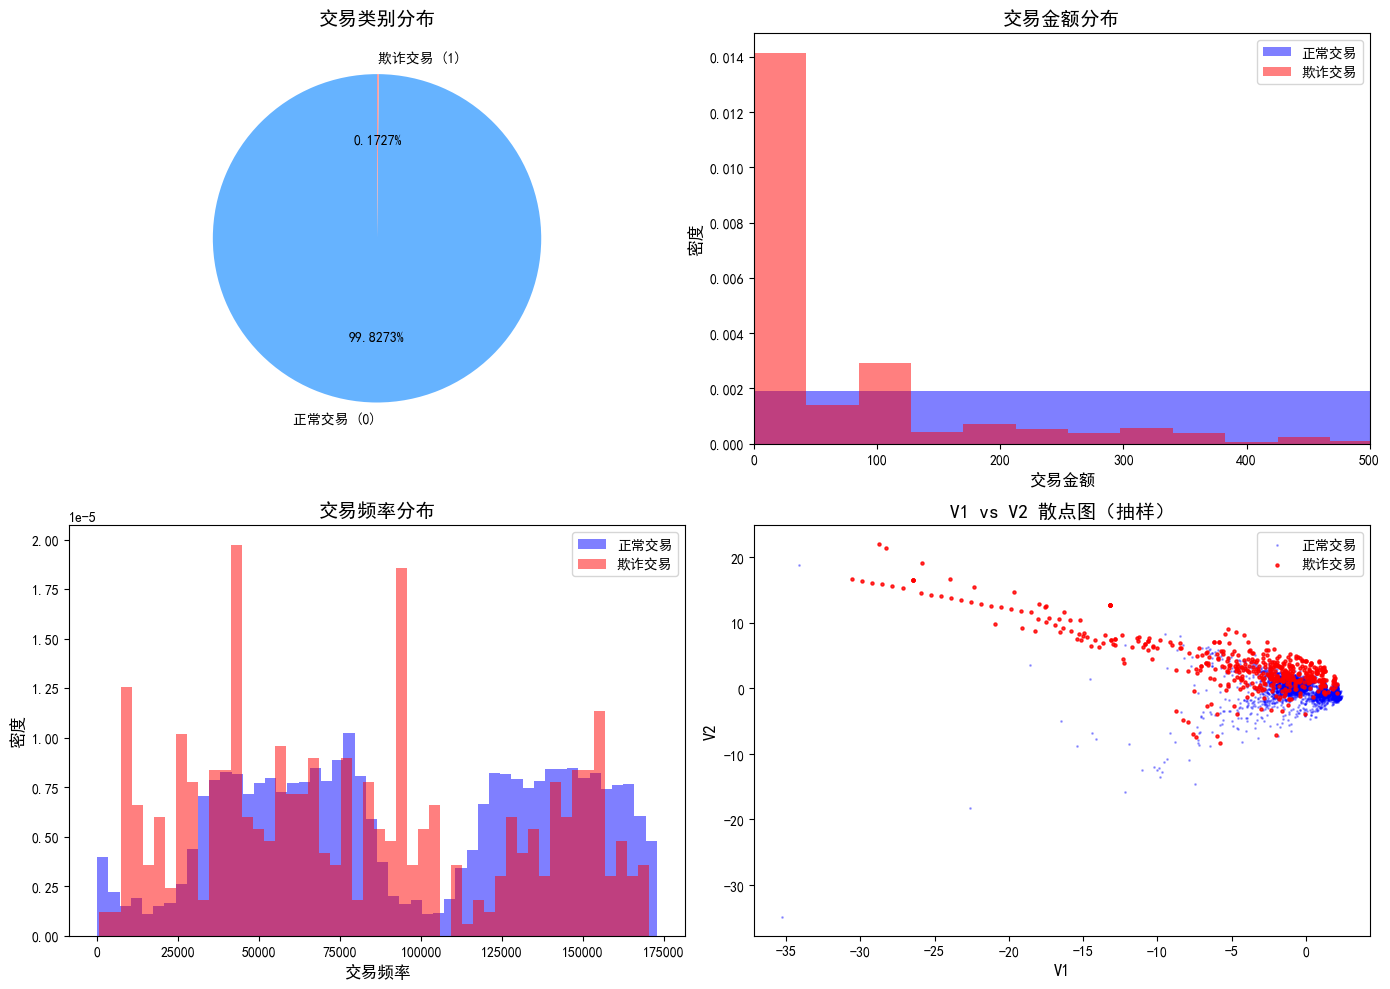

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10));

# 1. 类别分布饼图
axes[0, 0].pie(class_counts.values, labels=['正常交易 (0)', '欺诈交易 (1)'], 
               autopct='%1.4f%%', startangle=90, colors=['#66b3ff', '#ff9999']);
axes[0, 0].set_title('交易类别分布', fontsize=14, fontweight='bold');

# 2. 交易金额分布
axes[0, 1].hist(df[df[COL_CLASS] == 0][COL_AMOUNT], bins=50, alpha=0.5, 
                label='正常交易', color='blue', density=True);
axes[0, 1].hist(df[df[COL_CLASS] == 1][COL_AMOUNT], bins=50, alpha=0.5, 
                label='欺诈交易', color='red', density=True);   
axes[0, 1].set_xlabel('交易金额', fontsize=12);
axes[0, 1].set_ylabel('密度', fontsize=12);
axes[0, 1].set_title('交易金额分布', fontsize=14, fontweight='bold');
axes[0, 1].legend();
axes[0, 1].set_xlim(0, 500);

# 3. 时间分布
axes[1, 0].hist(df[df[COL_CLASS] == 0][COL_TIME], bins=50, alpha=0.5, 
                label='正常交易', color='blue', density=True);
axes[1, 0].hist(df[df[COL_CLASS] == 1][COL_TIME], bins=50, alpha=0.5, 
                label='欺诈交易', color='red', density=True);
axes[1, 0].set_xlabel('交易频率', fontsize=12);
axes[1, 0].set_ylabel('密度', fontsize=12);
axes[1, 0].set_title('交易频率分布', fontsize=14, fontweight='bold');
axes[1, 0].legend()

# 4. V1 vs V2 散点图
sample_normal = df[df[COL_CLASS] == 0].sample(min(5000, len(df[df[COL_CLASS] == 0])));
sample_fraud = df[df[COL_CLASS] == 1];
axes[1, 1].scatter(sample_normal['V1'], sample_normal['V2'], 
                   alpha=0.3, label='正常交易', color='blue', s=1);
axes[1, 1].scatter(sample_fraud['V1'], sample_fraud['V2'], 
                   alpha=0.8, label='欺诈交易', color='red', s=5);
axes[1, 1].set_xlabel('V1', fontsize=12);
axes[1, 1].set_ylabel('V2', fontsize=12);
axes[1, 1].set_title('V1 vs V2 散点图（抽样）', fontsize=14, fontweight='bold');
axes[1, 1].legend();

plt.tight_layout();
plt.savefig('data_exploration.png', dpi=150, bbox_inches='tight');  
print("可视化已保存到: data_exploration.png");
plt.show();

In [5]:
# 分离特征和目标
X = df.drop([COL_CLASS], axis=1);
y = df[COL_CLASS];

print(f"特征矩阵形状: {X.shape}");
print(f"目标向量形状: {y.shape}");

# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
);

feature_names = X.columns.tolist();

print(f"\n训练集大小: {X_train.shape[0]}");
print(f"测试集大小: {X_test.shape[0]}");
print(f"训练集欺诈比例: {y_train.sum() / len(y_train) * 100:.4f}%");
print(f"测试集欺诈比例: {y_test.sum() / len(y_test) * 100:.4f}%");


特征矩阵形状: (284807, 30)
目标向量形状: (284807,)

训练集大小: 227845
测试集大小: 56962
训练集欺诈比例: 0.1729%
测试集欺诈比例: 0.1720%


## 训练:

In [6]:
dt_basic = DecisionTreeClassifier(random_state=42);
dt_basic.fit(X_train, y_train);

y_pred_basic = dt_basic.predict(X_test);
y_prob_basic = dt_basic.predict_proba(X_test)[:, 1];

print(f"训练集准确率: {dt_basic.score(X_train, y_train):.4f}");
print(f"测试集准确率: {dt_basic.score(X_test, y_test):.4f}");
print(f"AUC-ROC: {roc_auc_score(y_test, y_prob_basic):.4f}");
print(f"树深度: {dt_basic.get_depth()}");
print(f"叶子节点数: {dt_basic.get_n_leaves()}");

训练集准确率: 1.0000
测试集准确率: 0.9991
AUC-ROC: 0.8722
树深度: 26
叶子节点数: 163


In [7]:
# 限制深度的决策树（防止过拟合）。
dt_limited = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42
);
dt_limited.fit(X_train, y_train);

y_pred_limited = dt_limited.predict(X_test);
y_prob_limited = dt_limited.predict_proba(X_test)[:, 1];

print(f"训练集准确率: {dt_limited.score(X_train, y_train):.4f}");
print(f"测试集准确率: {dt_limited.score(X_test, y_test):.4f}");
print(f"AUC-ROC: {roc_auc_score(y_test, y_prob_limited):.4f}");
print(f"树深度: {dt_limited.get_depth()}");
print(f"叶子节点数: {dt_limited.get_n_leaves()}");

训练集准确率: 0.9995
测试集准确率: 0.9993
AUC-ROC: 0.9013
树深度: 5
叶子节点数: 20


In [8]:
# 类别权重平衡的决策树。
dt_balanced = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=20,
    min_samples_leaf=10,
    class_weight='balanced',
    random_state=42
);
dt_balanced.fit(X_train, y_train);

y_pred_balanced = dt_balanced.predict(X_test);
y_prob_balanced = dt_balanced.predict_proba(X_test)[:, 1];

print(f"训练集准确率: {dt_balanced.score(X_train, y_train):.4f}");
print(f"测试集准确率: {dt_balanced.score(X_test, y_test):.4f}");
print(f"AUC-ROC: {roc_auc_score(y_test, y_prob_balanced):.4f}");
print(f"Average Precision: {average_precision_score(y_test, y_prob_balanced):.4f}");


训练集准确率: 0.9711
测试集准确率: 0.9694
AUC-ROC: 0.9166
Average Precision: 0.4498


In [9]:
param_grid = {
    'max_depth': [3, 5, 7, 10],
    'min_samples_split': [10, 20, 50],
    'min_samples_leaf': [5, 10, 20],
    'class_weight': ['balanced', None]
};

dt = DecisionTreeClassifier(random_state=42);

# 使用PR-AUC作为评分标准（更适合不平衡数据）。
grid_search = GridSearchCV(
    dt, param_grid, 
    scoring='average_precision',
    cv=3,
    n_jobs=-1,
    verbose=1
);

print("开始网格搜索...");
grid_search.fit(X_train, y_train);

print(f"\n最佳参数: {grid_search.best_params_}");
print(f"最佳交叉验证得分: {grid_search.best_score_:.4f}");

best_model = grid_search.best_estimator_;

开始网格搜索...
Fitting 3 folds for each of 72 candidates, totalling 216 fits

最佳参数: {'class_weight': None, 'max_depth': 10, 'min_samples_leaf': 5, 'min_samples_split': 10}
最佳交叉验证得分: 0.7553


In [10]:
y_pred = best_model.predict(X_test);
y_prob = best_model.predict_proba(X_test)[:, 1];

print("--- 分类报告 ---");
print(classification_report(y_test, y_pred, target_names=['正常', '欺诈']));

print("\n--- 混淆矩阵 ---");
cm = confusion_matrix(y_test, y_pred);
print(cm)
print(f"\n真阴性 (TN): {cm[0, 0]}");
print(f"假阳性 (FP): {cm[0, 1]}");
print(f"假阴性 (FN): {cm[1, 0]}");
print(f"真阳性 (TP): {cm[1, 1]}");

# 详细指标
print("\n--- 详细指标 ---");
print(f"准确率 (Accuracy): {accuracy_score(y_test, y_pred):.4f}");
print(f"精确率 (Precision): {precision_score(y_test, y_pred):.4f}");
print(f"召回率 (Recall): {recall_score(y_test, y_pred):.4f}");
print(f"F1分数: {f1_score(y_test, y_pred):.4f}");
print(f"AUC-ROC: {roc_auc_score(y_test, y_prob):.4f}");
print(f"Average Precision: {average_precision_score(y_test, y_prob):.4f}");


--- 分类报告 ---
              precision    recall  f1-score   support

          正常       1.00      1.00      1.00     56864
          欺诈       0.93      0.77      0.84        98

    accuracy                           1.00     56962
   macro avg       0.96      0.88      0.92     56962
weighted avg       1.00      1.00      1.00     56962


--- 混淆矩阵 ---
[[56858     6]
 [   23    75]]

真阴性 (TN): 56858
假阳性 (FP): 6
假阴性 (FN): 23
真阳性 (TP): 75

--- 详细指标 ---
准确率 (Accuracy): 0.9995
精确率 (Precision): 0.9259
召回率 (Recall): 0.7653
F1分数: 0.8380
AUC-ROC: 0.8910
Average Precision: 0.7761


In [11]:
# 特征重要性
print("--- 特征重要性 (前10名) ---");
importance_df = pd.DataFrame({
    '特征': feature_names,
    '重要性': best_model.feature_importances_
}).sort_values('重要性', ascending=False);
print(importance_df.head(10).to_string(index=False));

--- 特征重要性 (前10名) ---
  特征      重要性
 V17 0.658510
 V14 0.109977
 V12 0.056633
 V10 0.056024
 V27 0.036131
 V26 0.021336
  V4 0.012460
 V16 0.012193
 V28 0.008701
交易频率 0.006995


评估图表已保存到: model_evaluation.png


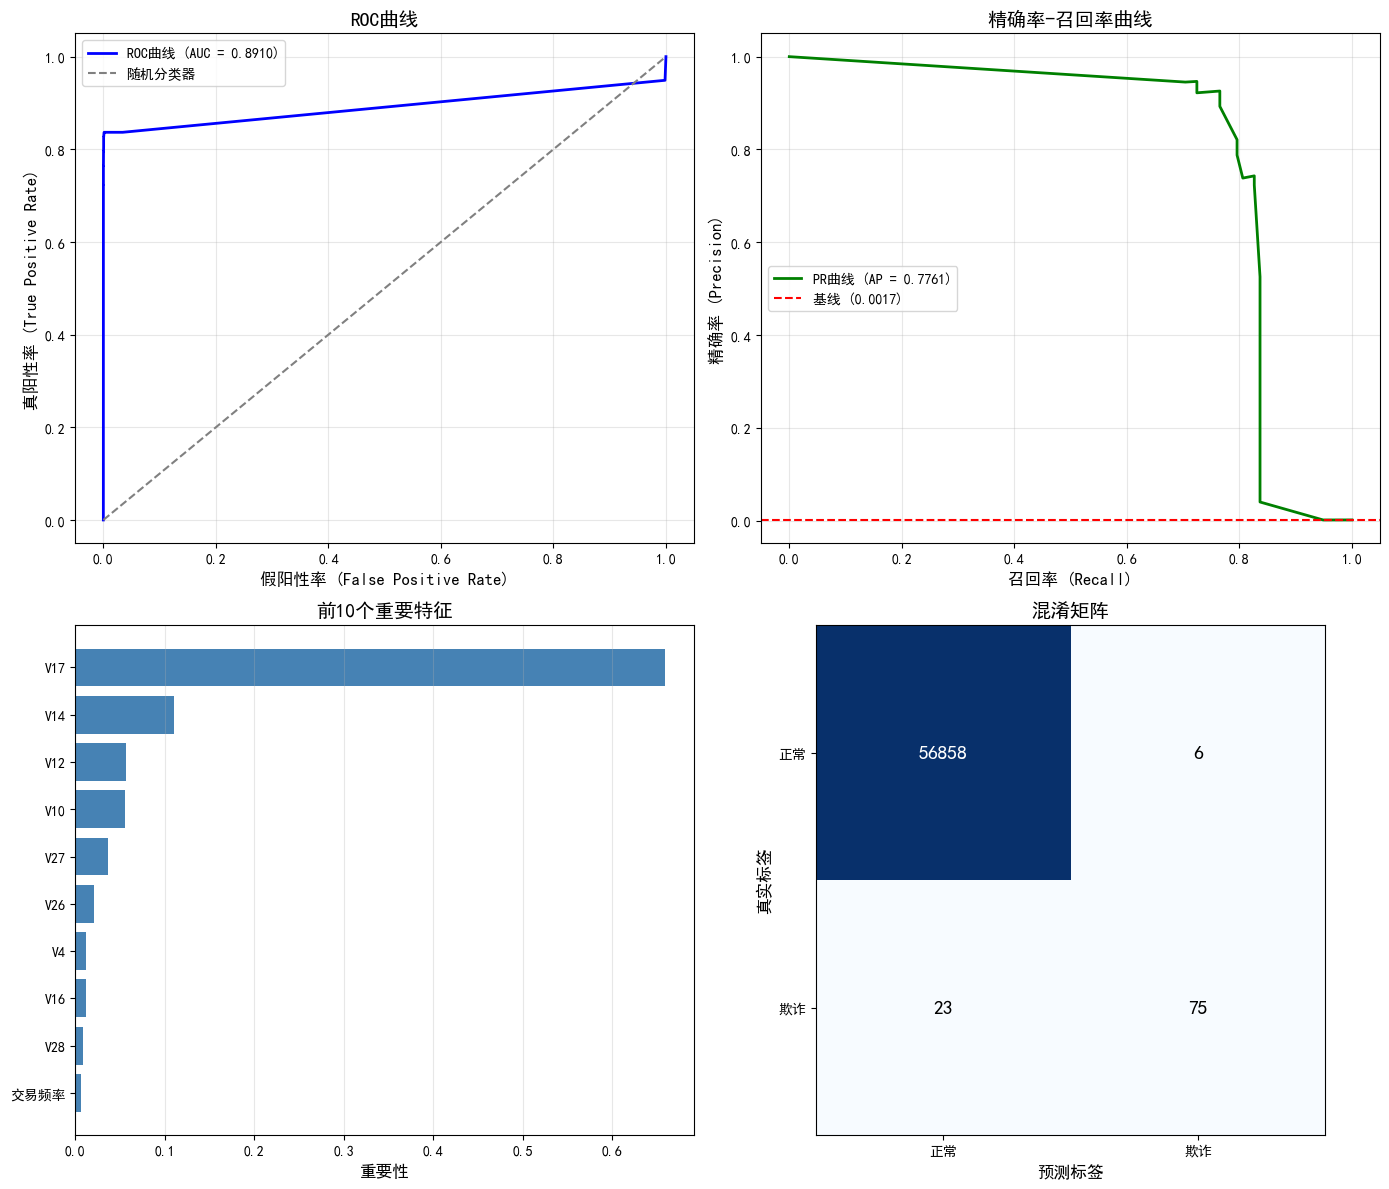

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12));

# 1. ROC曲线
fpr, tpr, _ = roc_curve(y_test, y_prob);
auc = roc_auc_score(y_test, y_prob);
axes[0, 0].plot(fpr, tpr, label=f'ROC曲线 (AUC = {auc:.4f})', linewidth=2, color='blue');
axes[0, 0].plot([0, 1], [0, 1], 'k--', label='随机分类器', color='gray');
axes[0, 0].set_xlabel('假阳性率 (False Positive Rate)', fontsize=12);
axes[0, 0].set_ylabel('真阳性率 (True Positive Rate)', fontsize=12);
axes[0, 0].set_title('ROC曲线', fontsize=14, fontweight='bold');
axes[0, 0].legend();
axes[0, 0].grid(True, alpha=0.3);

# 2. PR曲线
precision, recall, _ = precision_recall_curve(y_test, y_prob)
avg_precision = average_precision_score(y_test, y_prob)
axes[0, 1].plot(recall, precision, label=f'PR曲线 (AP = {avg_precision:.4f})', 
                linewidth=2, color='green')
axes[0, 1].axhline(y=y_test.mean(), color='r', linestyle='--', 
                   label=f'基线 ({y_test.mean():.4f})')
axes[0, 1].set_xlabel('召回率 (Recall)', fontsize=12)
axes[0, 1].set_ylabel('精确率 (Precision)', fontsize=12)
axes[0, 1].set_title('精确率-召回率曲线', fontsize=14, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. 特征重要性
top_features = importance_df.head(10)
axes[1, 0].barh(top_features['特征'][::-1], top_features['重要性'][::-1], color='steelblue')
axes[1, 0].set_xlabel('重要性', fontsize=12)
axes[1, 0].set_title('前10个重要特征', fontsize=14, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3, axis='x')

# 4. 混淆矩阵热力图
y_pred = best_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
im = axes[1, 1].imshow(cm, interpolation='nearest', cmap='Blues')
axes[1, 1].set_title('混淆矩阵', fontsize=14, fontweight='bold')
tick_marks = np.arange(2)
axes[1, 1].set_xticks(tick_marks)
axes[1, 1].set_yticks(tick_marks)
axes[1, 1].set_xticklabels(['正常', '欺诈'])
axes[1, 1].set_yticklabels(['正常', '欺诈'])
axes[1, 1].set_ylabel('真实标签', fontsize=12)
axes[1, 1].set_xlabel('预测标签', fontsize=12)

# 添加数值标注
thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        axes[1, 1].text(j, i, format(cm[i, j], 'd'),
                       ha="center", va="center",
                       color="white" if cm[i, j] > thresh else "black",
                       fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('model_evaluation.png', dpi=150, bbox_inches='tight')
print("评估图表已保存到: model_evaluation.png")
plt.show()

决策树结构图已保存到: decision_tree_structure.png


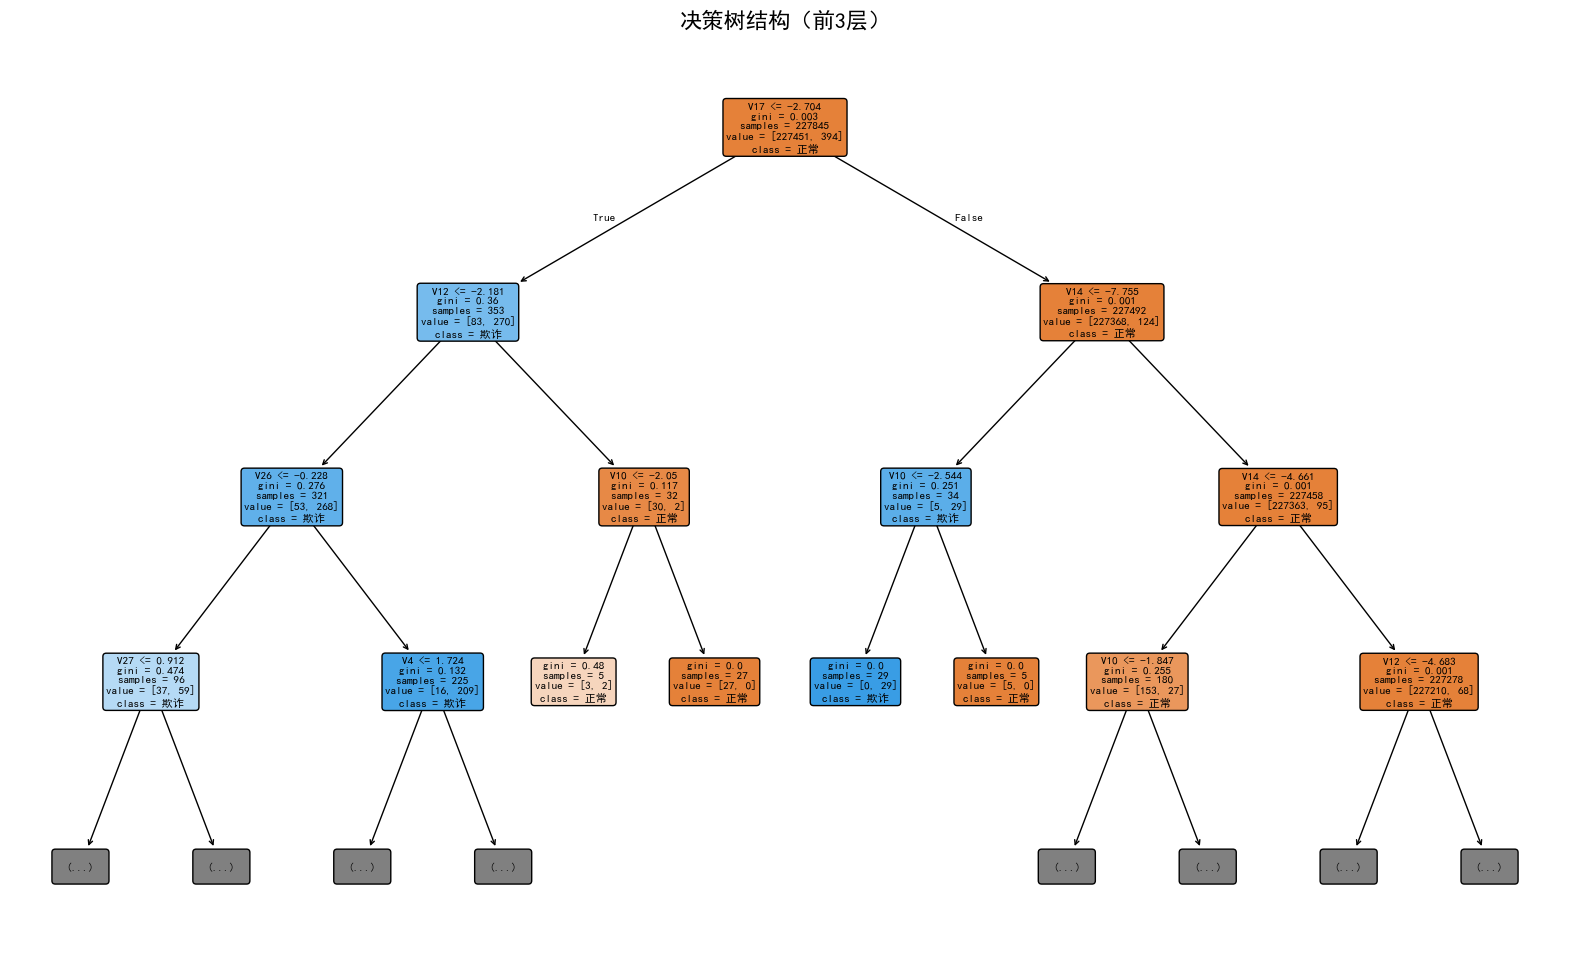

In [13]:
plt.figure(figsize=(20, 12));
plot_tree(best_model, 
          feature_names=feature_names,
          class_names=['正常', '欺诈'],
          filled=True,
          rounded=True,
          fontsize=8,
          max_depth=3); # 只显示前3层以便查看。

plt.title('决策树结构（前3层）', fontsize=16, fontweight='bold');
plt.savefig('decision_tree_structure.png', dpi=150, bbox_inches='tight');
print("决策树结构图已保存到: decision_tree_structure.png");
plt.show();

In [14]:
# 打印文本形式的决策规则
print("--- 决策规则 (前3层) ---")
tree_rules = export_text(best_model, feature_names=feature_names, max_depth=3);
print(tree_rules);

--- 决策规则 (前3层) ---
|--- V17 <= -2.70
|   |--- V12 <= -2.18
|   |   |--- V26 <= -0.23
|   |   |   |--- V27 <= 0.91
|   |   |   |   |--- truncated branch of depth 4
|   |   |   |--- V27 >  0.91
|   |   |   |   |--- truncated branch of depth 3
|   |   |--- V26 >  -0.23
|   |   |   |--- V4 <= 1.72
|   |   |   |   |--- truncated branch of depth 3
|   |   |   |--- V4 >  1.72
|   |   |   |   |--- truncated branch of depth 4
|   |--- V12 >  -2.18
|   |   |--- V10 <= -2.05
|   |   |   |--- class: 0
|   |   |--- V10 >  -2.05
|   |   |   |--- class: 0
|--- V17 >  -2.70
|   |--- V14 <= -7.75
|   |   |--- V10 <= -2.54
|   |   |   |--- class: 1
|   |   |--- V10 >  -2.54
|   |   |   |--- class: 0
|   |--- V14 >  -7.75
|   |   |--- V14 <= -4.66
|   |   |   |--- V10 <= -1.85
|   |   |   |   |--- truncated branch of depth 3
|   |   |   |--- V10 >  -1.85
|   |   |   |   |--- truncated branch of depth 3
|   |   |--- V14 >  -4.66
|   |   |   |--- V12 <= -4.68
|   |   |   |   |--- class: 0
|   |   |   |--- 

In [15]:
# 使用测试集的第一个样本
sample = X_test.iloc[0].values;
sample_df = pd.DataFrame([sample], columns=feature_names);
prediction = best_model.predict(sample_df)[0];
probability = best_model.predict_proba(sample_df)[0];

print(f"样本特征: {sample}");
print(f"预测结果: {'欺诈' if prediction == 1 else '正常'}");
print(f"预测概率: 正常={probability[0]:.4f}, 欺诈={probability[1]:.4f}");

样本特征: [ 1.60760000e+05 -6.74466065e-01  1.40810502e+00 -1.11062205e+00
 -1.32836578e+00  1.38899603e+00 -1.30843907e+00  1.88587890e+00
 -6.14232966e-01  3.11652212e-01  6.50757004e-01 -8.57784662e-01
 -2.29961446e-01 -1.99817005e-01  2.66371326e-01 -4.65441685e-02
 -7.41398090e-01 -6.05616644e-01 -3.92568188e-01 -1.62648311e-01
  3.94321821e-01  8.00842396e-02  8.10033596e-01 -2.24327230e-01
  7.07899237e-01 -1.35837023e-01  4.51021965e-02  5.33837219e-01
  2.91319253e-01  2.30000000e+01]
预测结果: 正常
预测概率: 正常=0.9998, 欺诈=0.0002
